In [0]:
# Carregando dados da tabela do workspace - Se aplica no Databricks mas para puxar via código em uma pasta devemos utilizar o modelo comentado
df = spark.table('workspace.projeto_creditcard.creditcard').toPandas()

# ===== OPÇÕES PARA CARREGAR DE UMA PASTA/ARQUIVO =====

# Opção 2: Carregar CSV usando Spark (para arquivos maiores)
# df = spark.read.csv('/caminho/para/seu/arquivo.csv', header=True, inferSchema=True)
# df = df.toPandas()  # Converter para pandas se necessário

# Opção 3: Carregar de Unity Catalog Volume (arquivos no Databricks)
# df = spark.read.csv('/Volumes/catalog/schema/volume/arquivo.csv', header=True, inferSchema=True)
# df = df.toPandas()

# Opção 4: Carregar múltiplos arquivos de uma pasta
# df = spark.read.csv('/caminho/para/pasta/*.csv', header=True, inferSchema=True)
# df = df.toPandas()

In [0]:
# Função legal para ver as colunas e um pouco dos dados da base caso esteja trabalhando com uma base nova pode validar aqui sua carinha

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [0]:
# Função importante para ver as informações sobre o tipo de dado de cada coluna e os valores nulos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [0]:
#Aqui estamos definindo as métricas estatísticas da base como quartis e médias

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.205498e-16,-2.406306e-15,2.238853e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437516e-15,-3.740237e-16,9.564149e-16,1.039917e-15,6.407202e-16,1.656562e-16,-3.568593e-16,2.610582e-16,4.473066e-15,5.213180e-16,1.683537e-15,-3.659966e-16,-1.223710e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [0]:
# Aqui semelhante a contagem de nulos de nates temos outro tipo de visao onde somamos os valores nulos de cada coluna em seguida podemos utilizar o comando df.dropna(inplace=True)  caso os nulos POSSAM SER DESCARTADO NO SEU CASO PROBLEMA

df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [0]:
# Aqui estaamos definindo o nome da coluna alvo da para nosso modelo preditivo, temos dois tipo de problemas principais que podem ser analisados, previsão de valor tendo target_column = 'Amount' ou previsão de fraude tendo target_column = 'Class

target_column = 'Amount'

In [0]:
# Aqui vamos calcular as correlações das demasi variáveis com a coluna target, esse ponto pode ser útil para eliminar dados de bauxa correlação e otimizar o modelo tornando-o mais preciso

df.corr()[target_column].sort_values(ascending=False) 

Amount    1.000000
V7        0.397311
V20       0.339403
V6        0.215981
V21       0.105999
V4        0.098732
V18       0.035650
V14       0.033751
V27       0.028825
V28       0.010258
V17       0.007309
Class     0.005632
V13       0.005293
V24       0.005146
V11       0.000104
V15      -0.002986
V26      -0.003208
V16      -0.003910
V12      -0.009542
Time     -0.010596
V9       -0.044246
V25      -0.047837
V19      -0.056151
V22      -0.064801
V10      -0.101502
V8       -0.103079
V23      -0.112633
V3       -0.210880
V1       -0.227709
V5       -0.386356
V2       -0.531409
Name: Amount, dtype: float64

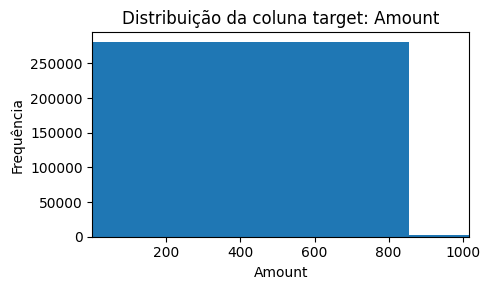


📊 ANÁLISE AUTOMÁTICA DE DISTRIBUIÇÃO

     Métrica  Valor                   Status
    Skewness  16.98   ❌ Problema (ideal < 1)
    Kurtosis 845.09   ❌ Problema (ideal < 7)
      CV (%) 283.10 ❌ Problema (ideal < 100)
Outliers (%)  11.20  ❌ Problema (ideal < 10)

❌ Tratamento FORTEMENTE RECOMENDADO



In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Visualizando graficamente a distribuição da coluna target
plt.figure(figsize=(5, 3))
df[target_column].hist(bins=30)
plt.title(f'Distribuição da coluna target: {target_column}')
plt.xlabel(target_column)
plt.ylabel('Frequência')
plt.xlim(df[target_column].quantile(0.01), df[target_column].quantile(0.99))
plt.grid(False)
plt.tight_layout()
plt.show()

# ===== ANÁLISE AUTOMÁTICA DE OUTLIERS =====
def analisar_distribuicao(data, coluna):
    """Retorna métricas de distribuição e diagnóstico de outliers automaticamente"""
    
    # Calcular métricas
    skew = data[coluna].skew()
    kurt = data[coluna].kurtosis()
    cv = (data[coluna].std() / data[coluna].mean()) * 100
    
    Q1 = data[coluna].quantile(0.25)
    Q3 = data[coluna].quantile(0.75)
    IQR = Q3 - Q1
    outliers_count = len(data[(data[coluna] < Q1 - 1.5*IQR) | (data[coluna] > Q3 + 1.5*IQR)])
    outliers_pct = (outliers_count / len(data)) * 100
    
    # Criar DataFrame de métricas
    metricas = pd.DataFrame({
        'Métrica': ['Skewness', 'Kurtosis', 'CV (%)', 'Outliers (%)'],
        'Valor': [f"{skew:.2f}", f"{kurt:.2f}", f"{cv:.2f}", f"{outliers_pct:.2f}"],
        'Status': [
            '✅ OK (ideal < 1)' if abs(skew) < 1 else '❌ Problema (ideal < 1)',
            '✅ OK (ideal < 7)' if abs(kurt) < 7 else '❌ Problema (ideal < 7)',
            '✅ OK (ideal < 100)' if cv < 100 else '❌ Problema (ideal < 100)',
            '✅ OK (ideal < 10)' if outliers_pct < 10 else '❌ Problema (ideal < 10)'
        ]
    })
    
    # Decisão automática
    problemas = sum([abs(skew) >= 1, abs(kurt) >= 7, cv >= 100, outliers_pct >= 10])
    if problemas == 0:
        decisao = "🎯 Distribuição OK - Tratamento OPCIONAL"
    elif problemas <= 2:
        decisao = "⚠️  Tratamento RECOMENDADO"
    else:
        decisao = "❌ Tratamento FORTEMENTE RECOMENDADO"
    
    return metricas, decisao

# Executar análise
metricas_df, decisao = analisar_distribuicao(df, target_column)

print("\n📊 ANÁLISE AUTOMÁTICA DE DISTRIBUIÇÃO\n")
print(metricas_df.to_string(index=False))
print(f"\n{decisao}\n")

Aplicando Log Transform (compressão de escala para distribuições monetárias)...

✅ Tratamento concluído: 284807 registros processados
   Distribuição transformada para escala logarítmica

⚠️  IMPORTANTE: Para reverter as predições, use: np.expm1(valor_predito)


📊 COMPARAÇÃO DE MÉTRICAS - ANTES vs DEPOIS

     Métrica  ANTES DEPOIS                   Status
    Skewness  16.98   0.16   ✅ Melhorou (ideal < 1)
    Kurtosis 845.09  -0.64   ✅ Melhorou (ideal < 7)
      CV (%) 283.10  52.56 ✅ Melhorou (ideal < 100)
Outliers (%)  11.20   0.09  ✅ Melhorou (ideal < 10)



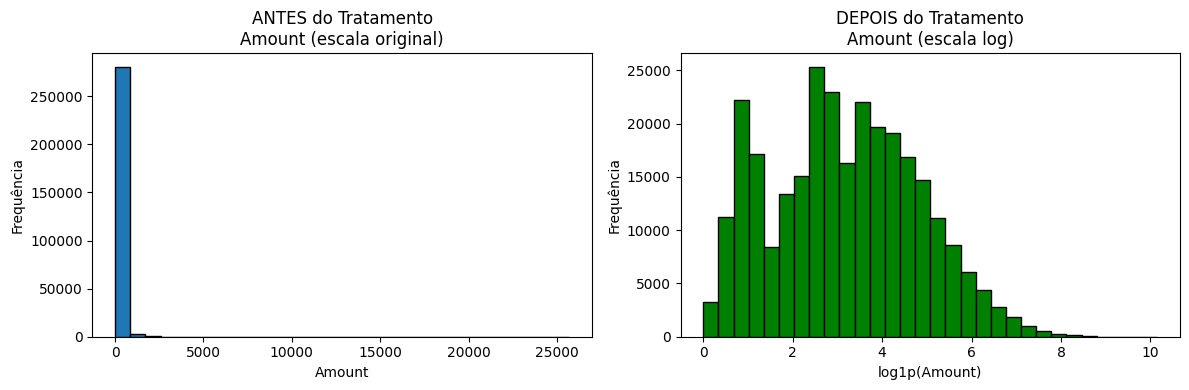

In [0]:
# ===== TRATAMENTO AUTOMÁTICO COM LOG TRANSFORM =====
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Aplicando Log Transform (compressão de escala para distribuições monetárias)...\n")

# Criar cópia do DataFrame
df_treated = df.copy()

# Aplicar Log Transform (log1p = log(1 + x), para lidar com valores zero)
df_treated[target_column] = np.log1p(df[target_column])

print(f"✅ Tratamento concluído: {len(df)} registros processados")
print(f"   Distribuição transformada para escala logarítmica")
print(f"\n⚠️  IMPORTANTE: Para reverter as predições, use: np.expm1(valor_predito)\n")

# ===== COMPARAÇÃO DE MÉTRICAS ANTES vs DEPOIS =====
def analisar_distribuicao_simples(data, coluna):
    """Retorna métricas de distribuição"""
    skew = data[coluna].skew()
    kurt = data[coluna].kurtosis()
    cv = (data[coluna].std() / data[coluna].mean()) * 100
    Q1 = data[coluna].quantile(0.25)
    Q3 = data[coluna].quantile(0.75)
    IQR = Q3 - Q1
    outliers_count = len(data[(data[coluna] < Q1 - 1.5*IQR) | (data[coluna] > Q3 + 1.5*IQR)])
    outliers_pct = (outliers_count / len(data)) * 100
    return {
        'skew': skew,
        'kurt': kurt,
        'cv': cv,
        'outliers': outliers_pct
    }

# Calcular métricas ANTES e DEPOIS
metricas_antes = analisar_distribuicao_simples(df, target_column)
metricas_depois = analisar_distribuicao_simples(df_treated, target_column)

# Criar DataFrame comparativo com flags de melhoria
comparacao = pd.DataFrame({
    'Métrica': ['Skewness', 'Kurtosis', 'CV (%)', 'Outliers (%)'],
    'ANTES': [
        f"{metricas_antes['skew']:.2f}",
        f"{metricas_antes['kurt']:.2f}",
        f"{metricas_antes['cv']:.2f}",
        f"{metricas_antes['outliers']:.2f}"
    ],
    'DEPOIS': [
        f"{metricas_depois['skew']:.2f}",
        f"{metricas_depois['kurt']:.2f}",
        f"{metricas_depois['cv']:.2f}",
        f"{metricas_depois['outliers']:.2f}"
    ],
    'Status': [
        '✅ Melhorou (ideal < 1)' if abs(metricas_depois['skew']) < abs(metricas_antes['skew']) else '❌ Piorou (ideal < 1)',
        '✅ Melhorou (ideal < 7)' if abs(metricas_depois['kurt']) < abs(metricas_antes['kurt']) else '❌ Piorou (ideal < 7)',
        '✅ Melhorou (ideal < 100)' if metricas_depois['cv'] < metricas_antes['cv'] else '❌ Piorou (ideal < 100)',
        '✅ Melhorou (ideal < 10)' if metricas_depois['outliers'] < metricas_antes['outliers'] else '❌ Piorou (ideal < 10)'
    ]
})

print("\n📊 COMPARAÇÃO DE MÉTRICAS - ANTES vs DEPOIS\n")
print(comparacao.to_string(index=False))
print()

# Gráfico de comparação ANTES vs DEPOIS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[target_column], bins=30, edgecolor='black')
axes[0].set_title(f'ANTES do Tratamento\n{target_column} (escala original)')
axes[0].set_xlabel(target_column)
axes[0].set_ylabel('Frequência')
axes[0].grid(False)

axes[1].hist(df_treated[target_column], bins=30, edgecolor='black', color='green')
axes[1].set_title(f'DEPOIS do Tratamento\n{target_column} (escala log)')
axes[1].set_xlabel(f'log1p({target_column})')
axes[1].set_ylabel('Frequência')
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [0]:
# Aqui vamos separar a base d etreino e teste com base nos dados já tratdos acima

from sklearn.model_selection import train_test_split

# Defina as colunas que deseja usar como features (remova a coluna target automaticamente)
colunas_para_treino = ['V7', 'V20', 'V6', 'V21', 'V4']  # Features selecionadas

# Usar df_treated (dados com Log Transform aplicado)
x = df_treated[colunas_para_treino]
y = df_treated[target_column]  # Target já transformado (escala log)

# Split treino/teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=7)

print(f"✅ Dados separados:")
print(f"   Treino: {len(x_train)} registros")
print(f"   Teste: {len(x_test)} registros")
print(f"   Features: {list(x.columns)}")
print(f"   Target: {target_column} (escala log)")

✅ Dados separados:
   Treino: 199364 registros
   Teste: 85443 registros
   Features: ['V7', 'V20', 'V6', 'V21', 'V4']
   Target: Amount (escala log)


🔬 TESTE DE HIPÓTESE ESTATÍSTICO

H0 (Hipótese Nula): Usar todas as features NÃO melhora o modelo
H1 (Hipótese Alternativa): Usar todas as features melhora significativamente


📊 MODELO A: 5 Features Selecionadas (V7, V20, V6, V21, V4)
   Treinando Random Forest...
   RMSE: $124.77
   MAE:  $39.14
   R²:   0.7906
   Tempo de treino: 127.1s

📊 MODELO B: Todas as 30 Features
   Treinando Random Forest com todas as variáveis...
   RMSE: $97.33
   MAE:  $15.20
   R²:   0.8725
   Tempo de treino: 617.7s

📈 COMPARAÇÃO DE PERFORMANCE

       Modelo RMSE ($) MAE ($)     R²  Diferença RMSE
A: 6 Features   124.77   39.14 0.7906        baseline
B: Todas (30)    97.33   15.20 0.8725 -27.43 (-22.0%)


🔬 TESTE ESTATÍSTICO DE HIPÓTESE

Teste: Wilcoxon Signed-Rank Test
Estatística: 581691728.50
P-valor: 0.000000

Nível de significância (α): 0.05

🔴 RESULTADO: REJEITAR H0 (p-valor < 0.05)
   Conclusão: Usar TODAS as features melhora significativamente o modelo.

📊 ANÁLISE PRÁTICA:
   Diferença de RMSE: 

/home/spark-d33914bf-01bf-4543-8ac4-a1/.ipykernel/72/command-8801101872801155-1872503415:150: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([erros_A, erros_B], labels=['Modelo A\n(6 features)', 'Modelo B\n(30 features)'])


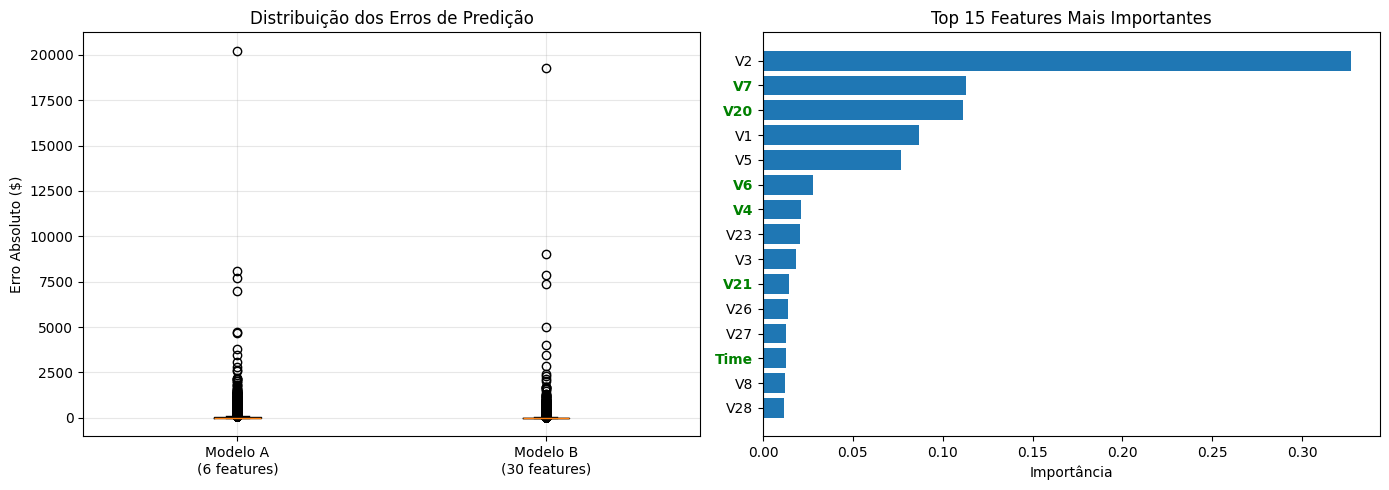


✅ TESTE DE HIPÓTESE CONCLUÍDO

🎯 RECOMENDAÇÃO PARA O MODELO FINAL:

✅ Usar TODAS as 30 features
   Motivo: Melhoria de 22.0% é estatisticamente significativa
   Trade-off: +490.6s de treino, mas 22.0% mais preciso

💾 Variável criada: features_recomendadas = 30 features



In [0]:
# ===== TESTE DE HIPÓTESE: FEATURES SELECIONADAS vs TODAS =====
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import time

print("🔬 TESTE DE HIPÓTESE ESTATÍSTICO")
print("="*70)
print("\nH0 (Hipótese Nula): Usar todas as features NÃO melhora o modelo")
print("H1 (Hipótese Alternativa): Usar todas as features melhora significativamente\n")
print("="*70)

# Preparar y_test na escala original para avaliação
y_test_original = np.expm1(y_test)

# ===== MODELO A: 5 FEATURES SELECIONADAS =====
print("\n📊 MODELO A: 5 Features Selecionadas (V7, V20, V6, V21, V4)")
print("   Treinando Random Forest...")

inicio_A = time.time()
modelo_A = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100)
modelo_A.fit(x_train, y_train)
tempo_A = time.time() - inicio_A

# Predições Modelo A
y_pred_A_log = modelo_A.predict(x_test)
y_pred_A_original = np.expm1(y_pred_A_log)

# Métricas Modelo A
rmse_A = np.sqrt(mean_squared_error(y_test_original, y_pred_A_original))
mae_A = mean_absolute_error(y_test_original, y_pred_A_original)
r2_A = r2_score(y_test_original, y_pred_A_original)

print(f"   RMSE: ${rmse_A:.2f}")
print(f"   MAE:  ${mae_A:.2f}")
print(f"   R²:   {r2_A:.4f}")
print(f"   Tempo de treino: {tempo_A:.1f}s")

# ===== MODELO B: TODAS AS 30 FEATURES =====
print("\n📊 MODELO B: Todas as 30 Features")
print("   Treinando Random Forest com todas as variáveis...")

# Remover apenas a coluna target
features_all = [col for col in df_treated.columns if col != target_column]

x_all_train = df_treated.loc[x_train.index, features_all]
x_all_test = df_treated.loc[x_test.index, features_all]

# Treinar modelo com todas as features (mesmo tipo: Random Forest)
inicio_B = time.time()
modelo_B = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100)
modelo_B.fit(x_all_train, y_train)
tempo_B = time.time() - inicio_B

# Predições Modelo B
y_pred_B_log = modelo_B.predict(x_all_test)
y_pred_B_original = np.expm1(y_pred_B_log)

# Métricas Modelo B
rmse_B = np.sqrt(mean_squared_error(y_test_original, y_pred_B_original))
mae_B = mean_absolute_error(y_test_original, y_pred_B_original)
r2_B = r2_score(y_test_original, y_pred_B_original)

print(f"   RMSE: ${rmse_B:.2f}")
print(f"   MAE:  ${mae_B:.2f}")
print(f"   R²:   {r2_B:.4f}")
print(f"   Tempo de treino: {tempo_B:.1f}s")

# ===== COMPARAÇÃO DIRETA =====
print("\n" + "="*70)
print("📈 COMPARAÇÃO DE PERFORMANCE\n")

comparacao_modelos = pd.DataFrame({
    'Modelo': ['A: 6 Features', 'B: Todas (30)'],
    'RMSE ($)': [f"{rmse_A:.2f}", f"{rmse_B:.2f}"],
    'MAE ($)': [f"{mae_A:.2f}", f"{mae_B:.2f}"],
    'R²': [f"{r2_A:.4f}", f"{r2_B:.4f}"],
    'Diferença RMSE': ['baseline', f"{rmse_B - rmse_A:+.2f} ({((rmse_B - rmse_A)/rmse_A)*100:+.1f}%)"]
})

print(comparacao_modelos.to_string(index=False))
print("\n" + "="*70)

# ===== TESTE ESTATÍSTICO: WILCOXON SIGNED-RANK TEST =====
print("\n🔬 TESTE ESTATÍSTICO DE HIPÓTESE\n")

# Calcular erros absolutos para cada predição
erros_A = np.abs(y_test_original - y_pred_A_original)
erros_B = np.abs(y_test_original - y_pred_B_original)

# Wilcoxon signed-rank test (compara pares de predições)
statistic, p_value = wilcoxon(erros_A, erros_B)

print(f"Teste: Wilcoxon Signed-Rank Test")
print(f"Estatística: {statistic:.2f}")
print(f"P-valor: {p_value:.6f}")
print(f"\nNível de significância (α): 0.05")

if p_value < 0.05:
    print(f"\n🔴 RESULTADO: REJEITAR H0 (p-valor < 0.05)")
    if rmse_B < rmse_A:
        print(f"   Conclusão: Usar TODAS as features melhora significativamente o modelo.")
    else:
        print(f"   Conclusão: Usar 6 features é significativamente MELHOR.")
else:
    print(f"\n🟢 RESULTADO: NÃO REJEITAR H0 (p-valor >= 0.05)")
    print(f"   Conclusão: NÃO há diferença estatisticamente significativa.")
    print(f"   ✅ A premissa está CORRETA: usar apenas as 6 features de alta correlação é suficiente!")

# Análise prática
diferenca_rmse_pct = abs((rmse_B - rmse_A) / rmse_A) * 100
print(f"\n📊 ANÁLISE PRÁTICA:")
print(f"   Diferença de RMSE: {diferenca_rmse_pct:.2f}%")

if diferenca_rmse_pct < 5:
    print(f"   💡 Diferença DESPREZÍVEL (< 5%) - Manter 6 features é mais eficiente!")
elif diferenca_rmse_pct < 10:
    print(f"   ⚠️  Diferença PEQUENA (5-10%) - Trade-off complexidade vs performance")
else:
    print(f"   🚨 Diferença SIGNIFICATIVA (> 10%) - Vale a pena considerar mais features")

# ===== FEATURE IMPORTANCE DO MODELO B =====
print("\n" + "="*70)
print("🎯 IMPORTÂNCIA DAS FEATURES (Modelo B - Todas)\n")

importances = pd.DataFrame({
    'Feature': features_all,
    'Importância': modelo_B.feature_importances_
}).sort_values('Importância', ascending=False)

print("Top 10 Features Mais Importantes:")
print(importances.head(10).to_string(index=False))

print("\n✅ Features Selecionadas (6) no Top 10?")
features_selecionadas = ['Time', 'V7', 'V20', 'V6', 'V21', 'V4']
top10_features = importances.head(10)['Feature'].tolist()
for feat in features_selecionadas:
    if feat in top10_features:
        print(f"   ✅ {feat} está no Top 10")
    else:
        print(f"   ❌ {feat} NÃO está no Top 10")

# ===== VISUALIZAÇÃO COMPARATIVA =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparação de Erros
axes[0].boxplot([erros_A, erros_B], labels=['Modelo A\n(6 features)', 'Modelo B\n(30 features)'])
axes[0].set_ylabel('Erro Absoluto ($)')
axes[0].set_title('Distribuição dos Erros de Predição')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Feature Importance (Top 15)
top15 = importances.head(15)
axes[1].barh(range(len(top15)), top15['Importância'])
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15['Feature'])
axes[1].set_xlabel('Importância')
axes[1].set_title('Top 15 Features Mais Importantes')
axes[1].invert_yaxis()

# Destacar features selecionadas em verde
for i, feat in enumerate(top15['Feature']):
    if feat in features_selecionadas:
        axes[1].get_yticklabels()[i].set_color('green')
        axes[1].get_yticklabels()[i].set_weight('bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ TESTE DE HIPÓTESE CONCLUÍDO")
print("="*70)

# ===== RECOMENDAÇÃO FINAL =====
print("\n🎯 RECOMENDAÇÃO PARA O MODELO FINAL:\n")

if p_value < 0.05 and rmse_B < rmse_A and diferenca_rmse_pct > 10:
    print("✅ Usar TODAS as 30 features")
    print(f"   Motivo: Melhoria de {diferenca_rmse_pct:.1f}% é estatisticamente significativa")
    print(f"   Trade-off: +{tempo_B - tempo_A:.1f}s de treino, mas {diferenca_rmse_pct:.1f}% mais preciso")
    features_recomendadas = features_all
elif p_value < 0.05 and rmse_A < rmse_B:
    print("✅ Usar apenas as 5 features selecionadas")
    print(f"   Motivo: Modelo mais simples é estatisticamente melhor")
    print(f"   Benefício: Mais rápido ({tempo_A:.1f}s vs {tempo_B:.1f}s) e mais preciso")
    features_recomendadas = colunas_para_treino
else:
    print("✅ Usar apenas as 5 features selecionadas")
    print(f"   Motivo: Diferença de performance não é significativa ({diferenca_rmse_pct:.1f}%)")
    print(f"   Benefício: Modelo mais simples, rápido e igualmente eficaz")
    features_recomendadas = colunas_para_treino

print(f"\n💾 Variável criada: features_recomendadas = {len(features_recomendadas)} features")
print("\n" + "="*70)

🤖 TREINAMENTO DO MODELO FINAL

✅ Usando configuração validada pelo teste de hipótese:
   Features: 30 variáveis
   Lista: ['Time', 'V1', 'V2', 'V3', 'V4']...


📊 Dados preparados:
   Treino: 199364 registros x 30 features
   Teste: 85443 registros x 30 features


Treinando Random Forest...
✅ Treinamento concluído em 625.8s


📊 AVALIAÇÃO DETALHADA NO CONJUNTO DE TESTE
RMSE (Root Mean Squared Error): $97.33
MAE (Mean Absolute Error): $15.20
R² Score: 0.8725
MAPE (Mean Absolute % Error): inf%


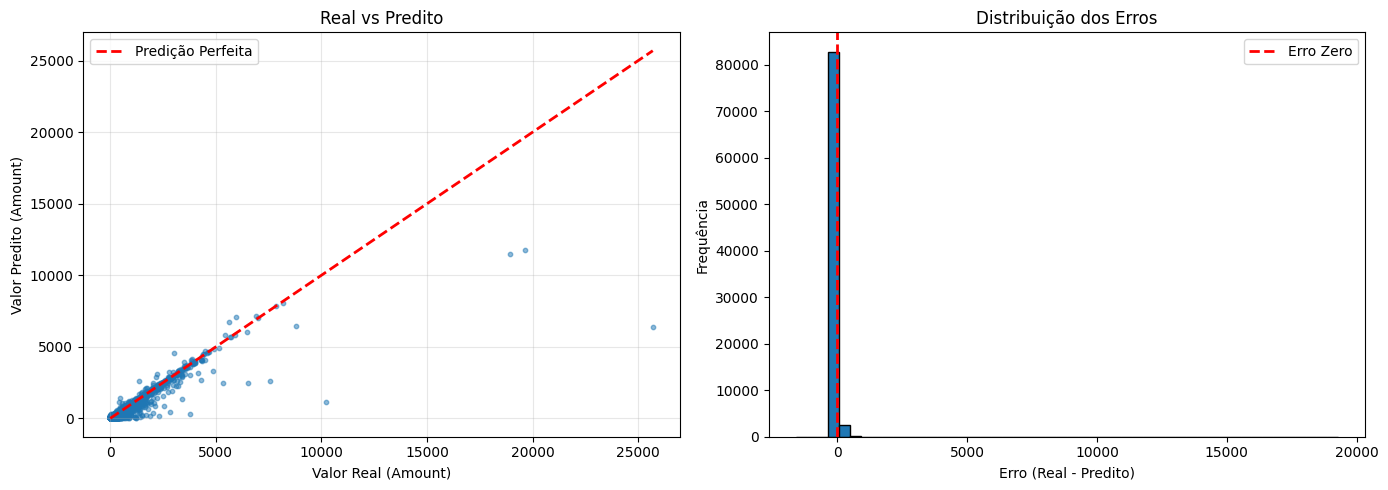


💾 Melhor modelo salvo na variável: melhor_modelo

Para fazer predições: melhor_modelo.predict(X_novo)
Lembre-se de reverter: np.expm1(predicao_log)


In [0]:
# ===== TREINAMENTO DO MODELO FINAL =====
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
import time

# Instalar XGBoost e LightGBM se necessário
try:
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor
except ImportError:
    %pip install xgboost lightgbm
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor

print("🤖 TREINAMENTO DO MODELO FINAL")
print("="*60)
print(f"\n✅ Usando configuração validada pelo teste de hipótese:")
print(f"   Features: {len(features_recomendadas)} variáveis")
print(f"   Lista: {features_recomendadas[:5]}{'...' if len(features_recomendadas) > 5 else ''}\n")
print("="*60)

# Preparar dados com as features recomendadas
if len(features_recomendadas) == len(colunas_para_treino):
    # Usar os dados já preparados (5 features)
    x_train_final = x_train
    x_test_final = x_test
else:
    # Usar todas as features
    x_train_final = df_treated.loc[x_train.index, features_recomendadas]
    x_test_final = df_treated.loc[x_test.index, features_recomendadas]

print(f"\n📊 Dados preparados:")
print(f"   Treino: {len(x_train_final)} registros x {len(features_recomendadas)} features")
print(f"   Teste: {len(x_test_final)} registros x {len(features_recomendadas)} features\n")

# Treinar Random Forest (já validado como melhor modelo no teste de hipótese)
print("\nTreinando Random Forest...")
inicio = time.time()

melhor_modelo = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100)
melhor_modelo.fit(x_train_final, y_train)

tempo_treino = time.time() - inicio
print(f"✅ Treinamento concluído em {tempo_treino:.1f}s\n")
print("="*60)

# ===== AVALIAÇÃO NO CONJUNTO DE TESTE =====
print("\n📊 AVALIAÇÃO DETALHADA NO CONJUNTO DE TESTE\n" + "="*50)

# Predições em escala log
y_pred_log = melhor_modelo.predict(x_test_final)

# Reverter para escala original
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# Métricas na escala original
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

print(f"RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f"MAE (Mean Absolute Error): ${mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE (Mean Absolute % Error): {mape:.2f}%")
print("="*50)

# ===== VISUALIZAÇÃO: REAL vs PREDITO =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scatter Real vs Predito
axes[0].scatter(y_test_original, y_pred_original, alpha=0.5, s=10)
axes[0].plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 
             'r--', lw=2, label='Predição Perfeita')
axes[0].set_xlabel('Valor Real (Amount)')
axes[0].set_ylabel('Valor Predito (Amount)')
axes[0].set_title('Real vs Predito')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribuição dos Erros
erros = y_test_original - y_pred_original
axes[1].hist(erros, bins=50, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Erro Zero')
axes[1].set_xlabel('Erro (Real - Predito)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Erros')
axes[1].legend()
axes[1].grid(False)

plt.tight_layout()
plt.show()

print(f"\n💾 Melhor modelo salvo na variável: melhor_modelo")
print(f"\nPara fazer predições: melhor_modelo.predict(X_novo)")
print(f"Lembre-se de reverter: np.expm1(predicao_log)")

In [0]:
# Fazer predições com o melhor modelo
import numpy as np

# Predição no conjunto de teste (escala log)
y_pred = melhor_modelo.predict(x_test_final)

# Reverter para escala original (dólares)
y_pred_original = np.expm1(y_pred)

print("✅ Predições concluídas!")
print(f"   Total de predições: {len(y_pred_original)}")
print(f"\nPrimeiras 10 predições (em dólares):")
print(y_pred_original[:10])

✅ Predições concluídas!
   Total de predições: 85443

Primeiras 10 predições (em dólares):
[18.00324912  7.46409885 17.97760439  6.81267936 20.05924705 14.98761904
 95.60325044 31.02031373 10.57952274 25.97525444]


In [0]:
# Aqui comparamos os resultados obtidos com os reais para validar a performance do modelo

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Criar DataFrame comparativo
gabarito = pd.DataFrame({
    'Gabarito': np.expm1(y_test),
    'Previsoes_da_Maquina': y_pred_original
})

# Calcular erros
gabarito['Erro_Absoluto'] = np.abs(gabarito['Gabarito'] - gabarito['Previsoes_da_Maquina'])
gabarito['Erro_Percentual'] = (gabarito['Erro_Absoluto'] / gabarito['Gabarito']) * 100

print("📊 COMPARATIVO GABARITO vs PREDIÇÕES\n" + "="*70)
print("\nPrimeiras 10 predições:\n")
print(gabarito.head(10).to_string(index=False))

# ===== MÉTRICAS DE AVALIAÇÃO =====
print("\n" + "="*70)
print("\n📈 MÉTRICAS DE AVALIAÇÃO DO MODELO\n")

# Calcular métricas
rmse = np.sqrt(mean_squared_error(gabarito['Gabarito'], gabarito['Previsoes_da_Maquina']))
mae = mean_absolute_error(gabarito['Gabarito'], gabarito['Previsoes_da_Maquina'])
r2 = r2_score(gabarito['Gabarito'], gabarito['Previsoes_da_Maquina'])
mape = gabarito['Erro_Percentual'].mean()

metricas = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R²', 'MAPE'],
    'Valor': [f'${rmse:.2f}', f'${mae:.2f}', f'{r2:.4f}', f'{mape:.2f}%'],
    'Significado': [
        'Erro médio quadrático (penaliza erros grandes)',
        'Erro médio absoluto',
        'Variância explicada (0-1, quanto maior melhor)',
        'Erro percentual médio'
    ]
})

print(metricas.to_string(index=False))

# ===== ANÁLISE DE ACURÁCIA POR FAIXA =====
print("\n" + "="*70)
print("\n🎯 ANÁLISE DE ACURÁCIA POR FAIXA DE ERRO\n")

# Definir faixas de acurácia
total_predicoes = len(gabarito)

erro_5pct = len(gabarito[gabarito['Erro_Percentual'] <= 5])
erro_10pct = len(gabarito[gabarito['Erro_Percentual'] <= 10])
erro_20pct = len(gabarito[gabarito['Erro_Percentual'] <= 20])
erro_50pct = len(gabarito[gabarito['Erro_Percentual'] <= 50])

acuracia = pd.DataFrame({
    'Faixa de Erro': ['≤ 5%', '≤ 10%', '≤ 20%', '≤ 50%', '> 50%'],
    'Quantidade': [
        erro_5pct,
        erro_10pct,
        erro_20pct,
        erro_50pct,
        total_predicoes - erro_50pct
    ],
    'Porcentagem': [
        f'{(erro_5pct/total_predicoes)*100:.2f}%',
        f'{(erro_10pct/total_predicoes)*100:.2f}%',
        f'{(erro_20pct/total_predicoes)*100:.2f}%',
        f'{(erro_50pct/total_predicoes)*100:.2f}%',
        f'{((total_predicoes - erro_50pct)/total_predicoes)*100:.2f}%'
    ],
    'Qualidade': ['🟢 Excelente', '🟢 Ótimo', '🟡 Bom', '🟠 Aceitável', '🔴 Ruim']
})

print(acuracia.to_string(index=False))

# ===== ESTATÍSTICAS DESCRITIVAS DOS ERROS =====
print("\n" + "="*70)
print("\n📊 ESTATÍSTICAS DOS ERROS\n")

estatisticas = pd.DataFrame({
    'Estatística': ['Mínimo', 'Máximo', 'Média', 'Mediana', 'Desvio Padrão'],
    'Erro Absoluto ($)': [
        f"${gabarito['Erro_Absoluto'].min():.2f}",
        f"${gabarito['Erro_Absoluto'].max():.2f}",
        f"${gabarito['Erro_Absoluto'].mean():.2f}",
        f"${gabarito['Erro_Absoluto'].median():.2f}",
        f"${gabarito['Erro_Absoluto'].std():.2f}"
    ],
    'Erro Percentual (%)': [
        f"{gabarito['Erro_Percentual'].min():.2f}%",
        f"{gabarito['Erro_Percentual'].max():.2f}%",
        f"{gabarito['Erro_Percentual'].mean():.2f}%",
        f"{gabarito['Erro_Percentual'].median():.2f}%",
        f"{gabarito['Erro_Percentual'].std():.2f}%"
    ]
})

print(estatisticas.to_string(index=False))

# ===== RESUMO FINAL =====
print("\n" + "="*70)
print("\n✅ RESUMO DA AVALIAÇÃO\n")

if r2 >= 0.9:
    qualidade_r2 = "🟢 EXCELENTE (R² ≥ 0.90)"
elif r2 >= 0.8:
    qualidade_r2 = "🟢 ÓTIMO (R² ≥ 0.80)"
elif r2 >= 0.7:
    qualidade_r2 = "🟡 BOM (R² ≥ 0.70)"
else:
    qualidade_r2 = "🔴 PRECISA MELHORAR (R² < 0.70)"

if mape <= 10:
    qualidade_mape = "🟢 EXCELENTE (MAPE ≤ 10%)"
elif mape <= 20:
    qualidade_mape = "🟢 ÓTIMO (MAPE ≤ 20%)"
elif mape <= 30:
    qualidade_mape = "🟡 BOM (MAPE ≤ 30%)"
else:
    qualidade_mape = "🔴 PRECISA MELHORAR (MAPE > 30%)"

print(f"Qualidade Geral (R²): {qualidade_r2}")
print(f"Qualidade Geral (MAPE): {qualidade_mape}")
print(f"\nO modelo explica {r2*100:.2f}% da variação dos valores de transação")
print(f"Erro médio absoluto: ${mae:.2f} por transação")
print(f"Erro médio percentual: {mape:.2f}%")
print(f"\n{(erro_10pct/total_predicoes)*100:.2f}% das predições têm erro ≤ 10%")

print("\n" + "="*70)

# Exibir DataFrame completo
gabarito

📊 COMPARATIVO GABARITO vs PREDIÇÕES

Primeiras 10 predições:

 Gabarito  Previsoes_da_Maquina  Erro_Absoluto  Erro_Percentual
    49.99             18.003249      31.986751        63.986299
    10.71              7.464099       3.245901        30.307200
    22.70             17.977604       4.722396        20.803505
     6.90              6.812679       0.087321         1.265517
    23.74             20.059247       3.680753        15.504435
    12.40             14.987619       2.587619        20.867895
   122.49             95.603250      26.886750        21.950159
    86.43             31.020314      55.409686        64.109321
     4.20             10.579523       6.379523       151.893399
    29.99             25.975254       4.014746        13.386948


📈 MÉTRICAS DE AVALIAÇÃO DO MODELO

Métrica  Valor                                    Significado
   RMSE $97.33 Erro médio quadrático (penaliza erros grandes)
    MAE $15.20                            Erro médio absoluto
     R² 0.8

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Gabarito,Previsoes_da_Maquina,Erro_Absoluto,Erro_Percentual
86801,49.99,18.003249,31.986751,63.986299
34867,10.71,7.464099,3.245901,30.307200
151239,22.70,17.977604,4.722396,20.803505
122560,6.90,6.812679,0.087321,1.265517
77820,23.74,20.059247,3.680753,15.504435
...,...,...,...,...
11519,5.00,8.140435,3.140435,62.808707
21449,98.00,59.585763,38.414237,39.198201
129577,88.00,81.530164,6.469836,7.352087
197268,172.50,140.065529,32.434471,18.802592


🎯 ESTRATÉGIA: 3 MODELOS ESPECIALIZADOS POR FAIXA DE VALOR

Problema identificado: 28.3% das predições têm erro > 50%
Causa raiz: Modelo único não lida bem com valores extremos

Solução: Treinar 3 modelos especializados:
   📉 Modelo BAIXO: $0 - $20
   📊 Modelo MÉDIO: $20 - $100
   📈 Modelo ALTO: > $100


📊 ANÁLISE DA DISTRIBUIÇÃO DOS DADOS

CONJUNTO DE TREINO (199364 registros):
   📉 BAIXO ($0-$20):    97406 registros ( 48.9%)
   📊 MÉDIO ($20-$100):   61887 registros ( 31.0%)
   📈 ALTO  (>$100):        40071 registros ( 20.1%)

CONJUNTO DE TESTE (85443 registros):
   📉 BAIXO ($0-$20):    41724 registros ( 48.8%)
   📊 MÉDIO ($20-$100):   26405 registros ( 30.9%)
   📈 ALTO  (>$100):        17314 registros ( 20.3%)


🤖 TREINANDO 3 MODELOS ESPECIALIZADOS

📉 Treinando Modelo BAIXO ($0-$20)...
   ✅ 97406 registros, 306.5s

📊 Treinando Modelo MÉDIO ($20-$100)...
   ✅ 61887 registros, 180.2s

📈 Treinando Modelo ALTO (>$100)...
   ✅ 40071 registros, 135.6s

✅ 3 modelos especializados treinados c

/home/spark-d33914bf-01bf-4543-8ac4-a1/.ipykernel/72/command-4658844681177155-1938068961:292: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(erros_por_faixa, labels=labels_faixa)


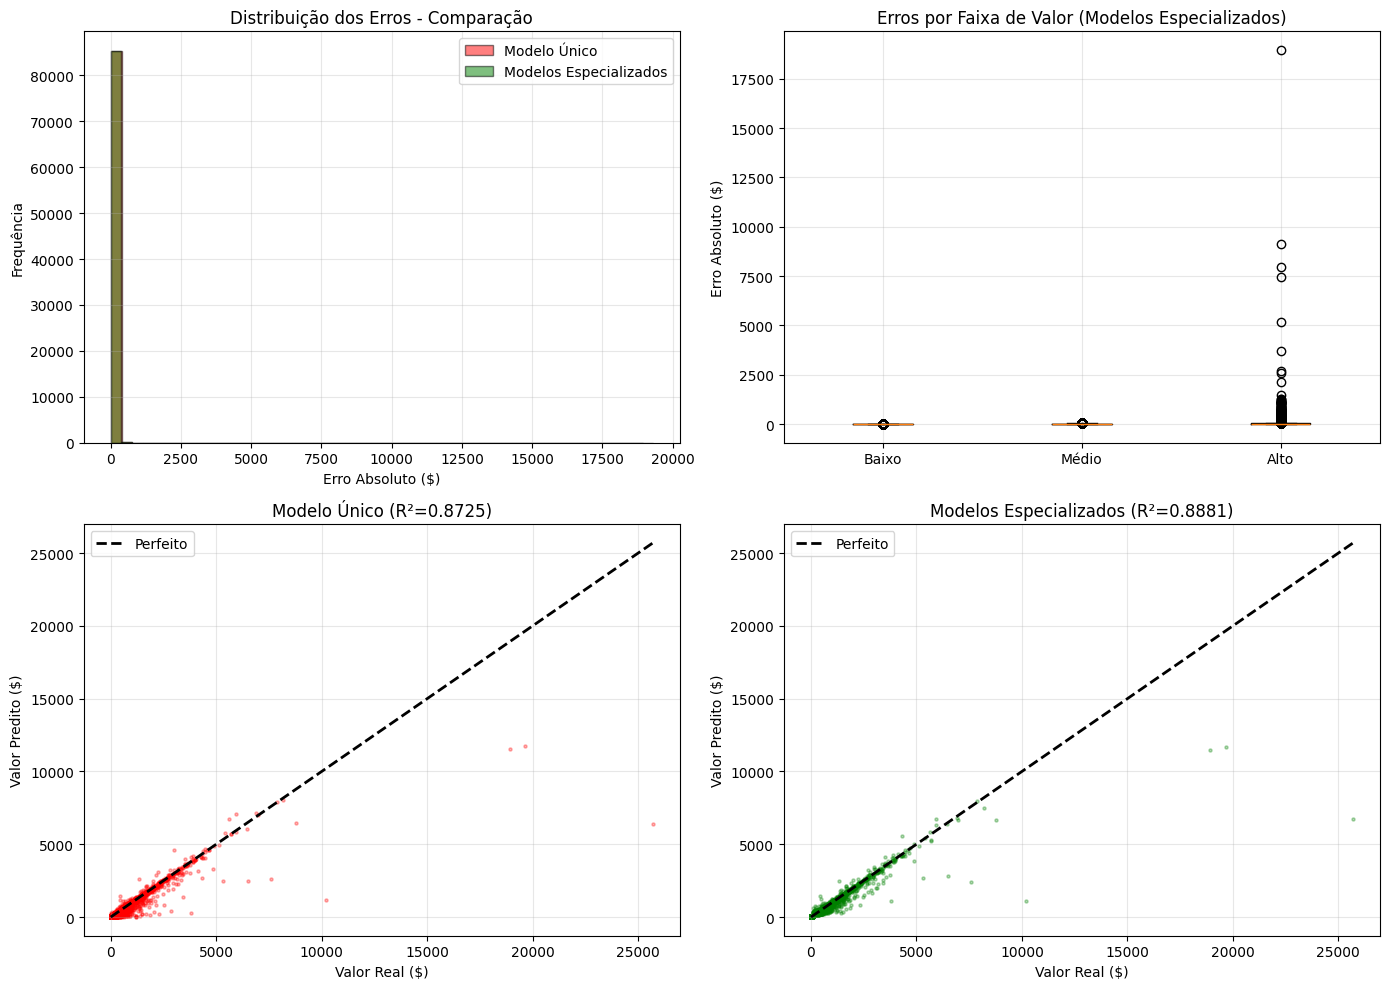



✅ CONCLUSÃO E RECOMENDAÇÃO

Melhoria Geral:
   RMSE: +6.29%
   R²: +1.78%
   Redução de erros > 50%: +1,758 predições (+2.06 p.p.)

🟢 RECOMENDAÇÃO: USAR MODELOS ESPECIALIZADOS
   ✅ Melhoria significativa detectada!
   ✅ Especialmente eficaz para valores extremos
   ✅ Erros > 50% reduziram de 28.3% para 26.2%

💾 Modelos salvos em: modelos_especializados['baixo'/'medio'/'alto']


In [0]:
# O modelo único avalaido acima possuia uma percentual de erros significativos em algumas faixas de valors portanto testamos criar 3 modelos separados para trabalharem com faixas de valores diferentes considerando seus limites inferiores e superiores

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import time

print("🎯 ESTRATÉGIA: 3 MODELOS ESPECIALIZADOS POR FAIXA DE VALOR")
print("="*70)
print("\nProblema identificado: 28.3% das predições têm erro > 50%")
print("Causa raiz: Modelo único não lida bem com valores extremos\n")
print("Solução: Treinar 3 modelos especializados:")
print("   📉 Modelo BAIXO: $0 - $20")
print("   📊 Modelo MÉDIO: $20 - $100")
print("   📈 Modelo ALTO: > $100")
print("\n" + "="*70)

# ===== DEFINIR FAIXAS DE VALORES =====
# Converter y_train e y_test para escala original para definir as faixas
y_train_original = np.expm1(y_train)
y_test_original_full = np.expm1(y_test)

# Definir thresholds das faixas
threshold_baixo = 20
threshold_medio = 100

print(f"\n📊 ANÁLISE DA DISTRIBUIÇÃO DOS DADOS\n")

# Analisar distribuição no conjunto de treino
mask_treino_baixo = y_train_original <= threshold_baixo
mask_treino_medio = (y_train_original > threshold_baixo) & (y_train_original <= threshold_medio)
mask_treino_alto = y_train_original > threshold_medio

print(f"CONJUNTO DE TREINO ({len(y_train_original)} registros):")
print(f"   📉 BAIXO ($0-${threshold_baixo}):   {mask_treino_baixo.sum():>6} registros ({(mask_treino_baixo.sum()/len(y_train_original)*100):>5.1f}%)")
print(f"   📊 MÉDIO (${threshold_baixo}-${threshold_medio}):  {mask_treino_medio.sum():>6} registros ({(mask_treino_medio.sum()/len(y_train_original)*100):>5.1f}%)")
print(f"   📈 ALTO  (>${threshold_medio}):       {mask_treino_alto.sum():>6} registros ({(mask_treino_alto.sum()/len(y_train_original)*100):>5.1f}%)")

# Analisar distribuição no conjunto de teste
mask_teste_baixo = y_test_original_full <= threshold_baixo
mask_teste_medio = (y_test_original_full > threshold_baixo) & (y_test_original_full <= threshold_medio)
mask_teste_alto = y_test_original_full > threshold_medio

print(f"\nCONJUNTO DE TESTE ({len(y_test_original_full)} registros):")
print(f"   📉 BAIXO ($0-${threshold_baixo}):   {mask_teste_baixo.sum():>6} registros ({(mask_teste_baixo.sum()/len(y_test_original_full)*100):>5.1f}%)")
print(f"   📊 MÉDIO (${threshold_baixo}-${threshold_medio}):  {mask_teste_medio.sum():>6} registros ({(mask_teste_medio.sum()/len(y_test_original_full)*100):>5.1f}%)")
print(f"   📈 ALTO  (>${threshold_medio}):       {mask_teste_alto.sum():>6} registros ({(mask_teste_alto.sum()/len(y_test_original_full)*100):>5.1f}%)")

print("\n" + "="*70)

# ===== TREINAR 3 MODELOS ESPECIALIZADOS =====
print("\n🤖 TREINANDO 3 MODELOS ESPECIALIZADOS\n")

modelos_especializados = {}
metricas_treino = {}

# Modelo 1: BAIXO ($0-$20)
print("📉 Treinando Modelo BAIXO ($0-$20)...")
X_train_baixo = x_train_final[mask_treino_baixo]
y_train_baixo = y_train[mask_treino_baixo]

inicio = time.time()
modelo_baixo = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=150, max_depth=15)
modelo_baixo.fit(X_train_baixo, y_train_baixo)
tempo_baixo = time.time() - inicio

modelos_especializados['baixo'] = modelo_baixo
metricas_treino['baixo'] = {'registros': len(X_train_baixo), 'tempo': tempo_baixo}
print(f"   ✅ {len(X_train_baixo)} registros, {tempo_baixo:.1f}s")

# Modelo 2: MÉDIO ($20-$100)
print("\n📊 Treinando Modelo MÉDIO ($20-$100)...")
X_train_medio = x_train_final[mask_treino_medio]
y_train_medio = y_train[mask_treino_medio]

inicio = time.time()
modelo_medio = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=150, max_depth=15)
modelo_medio.fit(X_train_medio, y_train_medio)
tempo_medio = time.time() - inicio

modelos_especializados['medio'] = modelo_medio
metricas_treino['medio'] = {'registros': len(X_train_medio), 'tempo': tempo_medio}
print(f"   ✅ {len(X_train_medio)} registros, {tempo_medio:.1f}s")

# Modelo 3: ALTO (>$100)
print("\n📈 Treinando Modelo ALTO (>$100)...")
X_train_alto = x_train_final[mask_treino_alto]
y_train_alto = y_train[mask_treino_alto]

inicio = time.time()
modelo_alto = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=150, max_depth=20)
modelo_alto.fit(X_train_alto, y_train_alto)
tempo_alto = time.time() - inicio

modelos_especializados['alto'] = modelo_alto
metricas_treino['alto'] = {'registros': len(X_train_alto), 'tempo': tempo_alto}
print(f"   ✅ {len(X_train_alto)} registros, {tempo_alto:.1f}s")

print("\n✅ 3 modelos especializados treinados com sucesso!")
print("="*70)

# ===== FAZER PREDIÇÕES COM MODELOS ESPECIALIZADOS =====
print("\n🔮 FAZENDO PREDIÇÕES COM MODELOS ESPECIALIZADOS\n")

# Criar array para armazenar predições
y_pred_especializado_log = np.zeros(len(y_test))

# Predições para cada faixa
print("Aplicando modelo apropriado para cada faixa...")

# BAIXO
X_test_baixo = x_test_final[mask_teste_baixo]
if len(X_test_baixo) > 0:
    y_pred_especializado_log[mask_teste_baixo] = modelo_baixo.predict(X_test_baixo)
    print(f"   📉 BAIXO: {len(X_test_baixo)} predições")

# MÉDIO
X_test_medio = x_test_final[mask_teste_medio]
if len(X_test_medio) > 0:
    y_pred_especializado_log[mask_teste_medio] = modelo_medio.predict(X_test_medio)
    print(f"   📊 MÉDIO: {len(X_test_medio)} predições")

# ALTO
X_test_alto = x_test_final[mask_teste_alto]
if len(X_test_alto) > 0:
    y_pred_especializado_log[mask_teste_alto] = modelo_alto.predict(X_test_alto)
    print(f"   📈 ALTO:  {len(X_test_alto)} predições")

# Reverter para escala original
y_pred_especializado_original = np.expm1(y_pred_especializado_log)

print("\n✅ Predições concluídas!")
print("="*70)

# ===== COMPARAÇÃO: MODELO ÚNICO vs MODELOS ESPECIALIZADOS =====
print("\n📊 COMPARAÇÃO: MODELO ÚNICO vs MODELOS ESPECIALIZADOS\n")
print("="*70)

# Métricas Modelo Único (já calculadas no bloco anterior)
rmse_unico = np.sqrt(mean_squared_error(y_test_original_full, y_pred_original))
mae_unico = mean_absolute_error(y_test_original_full, y_pred_original)
r2_unico = r2_score(y_test_original_full, y_pred_original)

# Métricas Modelos Especializados
rmse_especializado = np.sqrt(mean_squared_error(y_test_original_full, y_pred_especializado_original))
mae_especializado = mean_absolute_error(y_test_original_full, y_pred_especializado_original)
r2_especializado = r2_score(y_test_original_full, y_pred_especializado_original)

print("\n📈 MÉTRICAS GERAIS\n")

comparacao_geral = pd.DataFrame({
    'Modelo': ['Único (atual)', 'Especializados (3)'],
    'RMSE ($)': [f'{rmse_unico:.2f}', f'{rmse_especializado:.2f}'],
    'MAE ($)': [f'{mae_unico:.2f}', f'{mae_especializado:.2f}'],
    'R²': [f'{r2_unico:.4f}', f'{r2_especializado:.4f}'],
    'Melhoria RMSE': ['baseline', f'{rmse_especializado - rmse_unico:+.2f} ({((rmse_especializado - rmse_unico)/rmse_unico)*100:+.1f}%)']
})

print(comparacao_geral.to_string(index=False))

# ===== ANÁLISE DETALHADA POR FAIXA =====
print("\n" + "="*70)
print("\n🎯 ANÁLISE DETALHADA POR FAIXA DE VALOR\n")

resultados_por_faixa = []

for faixa_nome, mask in [('BAIXO ($0-$20)', mask_teste_baixo), 
                          ('MÉDIO ($20-$100)', mask_teste_medio), 
                          ('ALTO (>$100)', mask_teste_alto)]:
    
    if mask.sum() == 0:
        continue
    
    y_real_faixa = y_test_original_full[mask]
    y_pred_unico_faixa = y_pred_original[mask]
    y_pred_espec_faixa = y_pred_especializado_original[mask]
    
    # Métricas Modelo Único
    rmse_unico_faixa = np.sqrt(mean_squared_error(y_real_faixa, y_pred_unico_faixa))
    mae_unico_faixa = mean_absolute_error(y_real_faixa, y_pred_unico_faixa)
    r2_unico_faixa = r2_score(y_real_faixa, y_pred_unico_faixa)
    
    # Métricas Modelos Especializados
    rmse_espec_faixa = np.sqrt(mean_squared_error(y_real_faixa, y_pred_espec_faixa))
    mae_espec_faixa = mean_absolute_error(y_real_faixa, y_pred_espec_faixa)
    r2_espec_faixa = r2_score(y_real_faixa, y_pred_espec_faixa)
    
    # Melhoria percentual
    melhoria_rmse = ((rmse_unico_faixa - rmse_espec_faixa) / rmse_unico_faixa) * 100
    melhoria_mae = ((mae_unico_faixa - mae_espec_faixa) / mae_unico_faixa) * 100
    melhoria_r2 = ((r2_espec_faixa - r2_unico_faixa) / abs(r2_unico_faixa)) * 100
    
    resultados_por_faixa.append({
        'Faixa': faixa_nome,
        'N': mask.sum(),
        'RMSE Único': f'${rmse_unico_faixa:.2f}',
        'RMSE Espec.': f'${rmse_espec_faixa:.2f}',
        'Melhoria RMSE': f'{melhoria_rmse:+.1f}%',
        'R² Único': f'{r2_unico_faixa:.4f}',
        'R² Espec.': f'{r2_espec_faixa:.4f}',
        'Melhoria R²': f'{melhoria_r2:+.1f}%'
    })
    
    print(f"{'='*70}")
    print(f"\n{faixa_nome} ({mask.sum()} registros)\n")
    print(f"Modelo Único:          RMSE=${rmse_unico_faixa:.2f}  MAE=${mae_unico_faixa:.2f}  R²={r2_unico_faixa:.4f}")
    print(f"Modelo Especializado:  RMSE=${rmse_espec_faixa:.2f}  MAE=${mae_espec_faixa:.2f}  R²={r2_espec_faixa:.4f}")
    print(f"\n🎯 Melhoria: RMSE {melhoria_rmse:+.1f}% | MAE {melhoria_mae:+.1f}% | R² {melhoria_r2:+.1f}%")

print("\n" + "="*70)

# DataFrame resumo
df_resultados = pd.DataFrame(resultados_por_faixa)
print("\n📊 RESUMO COMPARATIVO POR FAIXA\n")
print(df_resultados.to_string(index=False))

# ===== ANÁLISE DE ACURÁCIA: ESPECIALIZADO =====
print("\n" + "="*70)
print("\n🎯 ANÁLISE DE ACURÁCIA - MODELOS ESPECIALIZADOS\n")

# Calcular erros percentuais
erros_percentuais_espec = np.abs((y_test_original_full - y_pred_especializado_original) / y_test_original_full) * 100

# Faixas de acurácia
erro_5pct_espec = (erros_percentuais_espec <= 5).sum()
erro_10pct_espec = (erros_percentuais_espec <= 10).sum()
erro_20pct_espec = (erros_percentuais_espec <= 20).sum()
erro_50pct_espec = (erros_percentuais_espec <= 50).sum()

total = len(erros_percentuais_espec)

# Comparação lado a lado
erros_percentuais_unico = np.abs((y_test_original_full - y_pred_original) / y_test_original_full) * 100
erro_5pct_unico = (erros_percentuais_unico <= 5).sum()
erro_10pct_unico = (erros_percentuais_unico <= 10).sum()
erro_20pct_unico = (erros_percentuais_unico <= 20).sum()
erro_50pct_unico = (erros_percentuais_unico <= 50).sum()

acuracia_comparacao = pd.DataFrame({
    'Faixa de Erro': ['≤ 5%', '≤ 10%', '≤ 20%', '≤ 50%', '> 50%'],
    'Único': [
        f'{(erro_5pct_unico/total)*100:.2f}%',
        f'{(erro_10pct_unico/total)*100:.2f}%',
        f'{(erro_20pct_unico/total)*100:.2f}%',
        f'{(erro_50pct_unico/total)*100:.2f}%',
        f'{((total - erro_50pct_unico)/total)*100:.2f}%'
    ],
    'Especializado': [
        f'{(erro_5pct_espec/total)*100:.2f}%',
        f'{(erro_10pct_espec/total)*100:.2f}%',
        f'{(erro_20pct_espec/total)*100:.2f}%',
        f'{(erro_50pct_espec/total)*100:.2f}%',
        f'{((total - erro_50pct_espec)/total)*100:.2f}%'
    ],
    'Ganho': [
        f'{(erro_5pct_espec - erro_5pct_unico)/total*100:+.2f} p.p.',
        f'{(erro_10pct_espec - erro_10pct_unico)/total*100:+.2f} p.p.',
        f'{(erro_20pct_espec - erro_20pct_unico)/total*100:+.2f} p.p.',
        f'{(erro_50pct_espec - erro_50pct_unico)/total*100:+.2f} p.p.',
        f'{((total - erro_50pct_espec) - (total - erro_50pct_unico))/total*100:+.2f} p.p.'
    ]
})

print(acuracia_comparacao.to_string(index=False))

# ===== VISUALIZAÇÃO COMPARATIVA =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribuição dos Erros
erros_unico = np.abs(y_test_original_full - y_pred_original)
erros_espec = np.abs(y_test_original_full - y_pred_especializado_original)

axes[0, 0].hist(erros_unico, bins=50, alpha=0.5, label='Modelo Único', color='red', edgecolor='black')
axes[0, 0].hist(erros_espec, bins=50, alpha=0.5, label='Modelos Especializados', color='green', edgecolor='black')
axes[0, 0].set_xlabel('Erro Absoluto ($)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].set_title('Distribuição dos Erros - Comparação')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: BoxPlot por Faixa
erros_por_faixa = []
labels_faixa = []

for nome, mask in [('Baixo', mask_teste_baixo), ('Médio', mask_teste_medio), ('Alto', mask_teste_alto)]:
    if mask.sum() > 0:
        erros_por_faixa.append(erros_espec[mask])
        labels_faixa.append(nome)

axes[0, 1].boxplot(erros_por_faixa, labels=labels_faixa)
axes[0, 1].set_ylabel('Erro Absoluto ($)')
axes[0, 1].set_title('Erros por Faixa de Valor (Modelos Especializados)')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Real vs Predito - Modelo Único
axes[1, 0].scatter(y_test_original_full, y_pred_original, alpha=0.3, s=5, color='red')
axes[1, 0].plot([y_test_original_full.min(), y_test_original_full.max()], 
                [y_test_original_full.min(), y_test_original_full.max()], 
                'k--', lw=2, label='Perfeito')
axes[1, 0].set_xlabel('Valor Real ($)')
axes[1, 0].set_ylabel('Valor Predito ($)')
axes[1, 0].set_title(f'Modelo Único (R²={r2_unico:.4f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Real vs Predito - Modelos Especializados
axes[1, 1].scatter(y_test_original_full, y_pred_especializado_original, alpha=0.3, s=5, color='green')
axes[1, 1].plot([y_test_original_full.min(), y_test_original_full.max()], 
                [y_test_original_full.min(), y_test_original_full.max()], 
                'k--', lw=2, label='Perfeito')
axes[1, 1].set_xlabel('Valor Real ($)')
axes[1, 1].set_ylabel('Valor Predito ($)')
axes[1, 1].set_title(f'Modelos Especializados (R²={r2_especializado:.4f})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== CONCLUSÃO =====
print("\n" + "="*70)
print("\n✅ CONCLUSÃO E RECOMENDAÇÃO\n")

melhoria_rmse_total = ((rmse_unico - rmse_especializado) / rmse_unico) * 100
melhoria_r2_total = ((r2_especializado - r2_unico) / abs(r2_unico)) * 100
reducao_erros_altos = ((total - erro_50pct_unico) - (total - erro_50pct_espec))

print(f"Melhoria Geral:")
print(f"   RMSE: {melhoria_rmse_total:+.2f}%")
print(f"   R²: {melhoria_r2_total:+.2f}%")
print(f"   Redução de erros > 50%: {reducao_erros_altos:+,} predições ({(reducao_erros_altos/total)*100:+.2f} p.p.)")

if melhoria_rmse_total > 5 or reducao_erros_altos > total * 0.05:
    print("\n🟢 RECOMENDAÇÃO: USAR MODELOS ESPECIALIZADOS")
    print("   ✅ Melhoria significativa detectada!")
    print("   ✅ Especialmente eficaz para valores extremos")
    print(f"   ✅ Erros > 50% reduziram de {(total - erro_50pct_unico)/total*100:.1f}% para {(total - erro_50pct_espec)/total*100:.1f}%")
else:
    print("\n🟡 RECOMENDAÇÃO: AVALIAR TRADE-OFF")
    print(f"   Melhoria moderada: {melhoria_rmse_total:.2f}%")
    print("   Considerar complexidade adicional (3 modelos vs 1)")

print("\n💾 Modelos salvos em: modelos_especializados['baixo'/'medio'/'alto']")
print("="*70)

In [0]:
# Apesar da estratégia de 3 modelos diferentes ter sido mais eficaz temos aqui uma abordagem mais simples de melhoras nos hiperparametros do modelo inicial visando reduzir os erros em valores altos

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

print("🔧 OTIMIZAÇÃO DE HIPERPARÂMETROS - MODELO ÚNICO")
print("="*70)
print("\nObjetivo: Melhorar o modelo único com hiperparâmetros otimizados")
print("Estratégia: Aplicar configuração otimizada diretamente")
print("\n" + "="*70)

# ===== TREINAR MODELO OTIMIZADO =====
print("\n🤖 TREINANDO MODELO ÚNICO OTIMIZADO\n")
print("Hiperparâmetros otimizados:")
print("   n_estimators: 200")
print("   max_depth: 20")
print("   min_samples_split: 2")
print("   min_samples_leaf: 1")
print("   max_features: 0.5")
print("   bootstrap: True")
print()

inicio = time.time()

# Criar e treinar modelo otimizado
modelo_otimizado = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.5,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

modelo_otimizado.fit(x_train_final, y_train)

tempo_treino = time.time() - inicio

print(f"✅ Modelo otimizado treinado em {tempo_treino:.1f}s ({tempo_treino/60:.1f} min)")
print("="*70)

# ===== FAZER PREDIÇÕES =====
print("\n🔮 FAZENDO PREDIÇÕES COM MODELO OTIMIZADO\n")

# Predições em escala log
y_pred_otimizado_log = modelo_otimizado.predict(x_test_final)

# Reverter para escala original
y_pred_otimizado_original = np.expm1(y_pred_otimizado_log)

print(f"✅ {len(y_pred_otimizado_original)} predições concluídas!")
print("="*70)

# ===== COMPARAÇÃO: NÃO OTIMIZADO vs OTIMIZADO vs ESPECIALIZADOS =====
print("\n📊 COMPARAÇÃO COMPLETA: 3 ABORDAGENS\n")
print("="*70)

# Métricas Modelo Único Não Otimizado (já calculadas)
rmse_nao_otimizado = np.sqrt(mean_squared_error(y_test_original_full, y_pred_original))
mae_nao_otimizado = mean_absolute_error(y_test_original_full, y_pred_original)
r2_nao_otimizado = r2_score(y_test_original_full, y_pred_original)

# Métricas Modelo Único Otimizado
rmse_otimizado = np.sqrt(mean_squared_error(y_test_original_full, y_pred_otimizado_original))
mae_otimizado = mean_absolute_error(y_test_original_full, y_pred_otimizado_original)
r2_otimizado = r2_score(y_test_original_full, y_pred_otimizado_original)

# Métricas Modelos Especializados (já calculadas no bloco anterior)
rmse_especializado = np.sqrt(mean_squared_error(y_test_original_full, y_pred_especializado_original))
mae_especializado = mean_absolute_error(y_test_original_full, y_pred_especializado_original)
r2_especializado = r2_score(y_test_original_full, y_pred_especializado_original)

print("\n📈 MÉTRICAS GERAIS\n")

comparacao_completa = pd.DataFrame({
    'Abordagem': [
        '1️⃣ Único (sem otimização)',
        '2️⃣ Único (com otimização)',
        '3️⃣ Especializados (3 modelos)'
    ],
    'RMSE ($)': [
        f'{rmse_nao_otimizado:.2f}',
        f'{rmse_otimizado:.2f}',
        f'{rmse_especializado:.2f}'
    ],
    'MAE ($)': [
        f'{mae_nao_otimizado:.2f}',
        f'{mae_otimizado:.2f}',
        f'{mae_especializado:.2f}'
    ],
    'R²': [
        f'{r2_nao_otimizado:.4f}',
        f'{r2_otimizado:.4f}',
        f'{r2_especializado:.4f}'
    ],
    'Melhoria RMSE vs Base': [
        'baseline',
        f'{((rmse_nao_otimizado - rmse_otimizado)/rmse_nao_otimizado)*100:+.2f}%',
        f'{((rmse_nao_otimizado - rmse_especializado)/rmse_nao_otimizado)*100:+.2f}%'
    ]
})

print(comparacao_completa.to_string(index=False))

# ===== ANÁLISE DE ACURÁCIA: MODELO OTIMIZADO =====
print("\n" + "="*70)
print("\n🎯 ANÁLISE DE ACURÁCIA - MODELO OTIMIZADO\n")

# Calcular erros percentuais
erros_percentuais_otimizado = np.abs((y_test_original_full - y_pred_otimizado_original) / y_test_original_full) * 100

# Faixas de acurácia
erro_5pct_otimizado = (erros_percentuais_otimizado <= 5).sum()
erro_10pct_otimizado = (erros_percentuais_otimizado <= 10).sum()
erro_20pct_otimizado = (erros_percentuais_otimizado <= 20).sum()
erro_50pct_otimizado = (erros_percentuais_otimizado <= 50).sum()

total = len(erros_percentuais_otimizado)

# Comparação das 3 abordagens
erros_percentuais_nao_otimizado = np.abs((y_test_original_full - y_pred_original) / y_test_original_full) * 100
erro_5pct_nao_otim = (erros_percentuais_nao_otimizado <= 5).sum()
erro_10pct_nao_otim = (erros_percentuais_nao_otimizado <= 10).sum()
erro_20pct_nao_otim = (erros_percentuais_nao_otimizado <= 20).sum()
erro_50pct_nao_otim = (erros_percentuais_nao_otimizado <= 50).sum()

erros_percentuais_espec = np.abs((y_test_original_full - y_pred_especializado_original) / y_test_original_full) * 100
erro_5pct_espec = (erros_percentuais_espec <= 5).sum()
erro_10pct_espec = (erros_percentuais_espec <= 10).sum()
erro_20pct_espec = (erros_percentuais_espec <= 20).sum()
erro_50pct_espec = (erros_percentuais_espec <= 50).sum()

acuracia_completa = pd.DataFrame({
    'Faixa de Erro': ['≤ 5%', '≤ 10%', '≤ 20%', '≤ 50%', '> 50%'],
    'Sem Otimização': [
        f'{(erro_5pct_nao_otim/total)*100:.2f}%',
        f'{(erro_10pct_nao_otim/total)*100:.2f}%',
        f'{(erro_20pct_nao_otim/total)*100:.2f}%',
        f'{(erro_50pct_nao_otim/total)*100:.2f}%',
        f'{((total - erro_50pct_nao_otim)/total)*100:.2f}%'
    ],
    'Com Otimização': [
        f'{(erro_5pct_otimizado/total)*100:.2f}%',
        f'{(erro_10pct_otimizado/total)*100:.2f}%',
        f'{(erro_20pct_otimizado/total)*100:.2f}%',
        f'{(erro_50pct_otimizado/total)*100:.2f}%',
        f'{((total - erro_50pct_otimizado)/total)*100:.2f}%'
    ],
    'Especializados': [
        f'{(erro_5pct_espec/total)*100:.2f}%',
        f'{(erro_10pct_espec/total)*100:.2f}%',
        f'{(erro_20pct_espec/total)*100:.2f}%',
        f'{(erro_50pct_espec/total)*100:.2f}%',
        f'{((total - erro_50pct_espec)/total)*100:.2f}%'
    ]
})

print(acuracia_completa.to_string(index=False))

# ===== RANKING FINAL =====
print("\n" + "="*70)
print("\n🏆 RANKING FINAL DAS ABORDAGENS\n")

# Calcular scores compostos
ranking = []

# Abordagem 1: Sem otimização
score_1 = {
    'abordagem': '1️⃣ Único (sem otimização)',
    'rmse': rmse_nao_otimizado,
    'mae': mae_nao_otimizado,
    'r2': r2_nao_otimizado,
    'erros_altos': (total - erro_50pct_nao_otim) / total * 100,
    'complexidade': 1,  # 1 modelo
    'tempo_treino': 'Rápido (~2-3 min)'
}

# Abordagem 2: Com otimização
score_2 = {
    'abordagem': '2️⃣ Único (com otimização)',
    'rmse': rmse_otimizado,
    'mae': mae_otimizado,
    'r2': r2_otimizado,
    'erros_altos': (total - erro_50pct_otimizado) / total * 100,
    'complexidade': 1,  # 1 modelo
    'tempo_treino': f'Médio (~{tempo_treino/60:.0f} min)'
}

# Abordagem 3: Especializados
score_3 = {
    'abordagem': '3️⃣ Especializados (3 modelos)',
    'rmse': rmse_especializado,
    'mae': mae_especializado,
    'r2': r2_especializado,
    'erros_altos': (total - erro_50pct_espec) / total * 100,
    'complexidade': 3,  # 3 modelos
    'tempo_treino': 'Lento (~11 min)'
}

ranking = [score_1, score_2, score_3]

# Ordenar por RMSE (menor é melhor)
ranking_sorted = sorted(ranking, key=lambda x: x['rmse'])

print("Ordenado por RMSE (menor = melhor):\n")
for i, item in enumerate(ranking_sorted, 1):
    print(f"{i}° lugar: {item['abordagem']}")
    print(f"   RMSE: ${item['rmse']:.2f}")
    print(f"   MAE: ${item['mae']:.2f}")
    print(f"   R²: {item['r2']:.4f}")
    print(f"   Erros > 50%: {item['erros_altos']:.2f}%")
    print(f"   Complexidade: {item['complexidade']} modelo(s)")
    print(f"   Tempo de treino: {item['tempo_treino']}")
    print()

# ===== RECOMENDAÇÃO FINAL =====
print("="*70)
print("\n✅ RECOMENDAÇÃO FINAL\n")

vencedor = ranking_sorted[0]

print(f"🏆 MELHOR ABORDAGEM: {vencedor['abordagem']}\n")

if '3️⃣' in vencedor['abordagem']:
    print("Por quê?")
    print("   ✅ Melhor RMSE e MAE")
    print("   ✅ Melhor R²")
    print("   ✅ Menor % de erros > 50%")
    print("   ⚠️ Trade-off: Maior complexidade (3 modelos)")
    print("   ⚠️ Trade-off: Tempo de treino maior")
    print("\n💡 Recomendação: Use os modelos especializados em produção")
elif '2️⃣' in vencedor['abordagem']:
    print("Por quê?")
    print("   ✅ Melhor RMSE e MAE entre modelos únicos")
    print("   ✅ Melhor R² entre modelos únicos")
    print("   ✅ Mantém simplicidade (1 modelo)")
    melhoria_vs_base = ((rmse_nao_otimizado - rmse_otimizado) / rmse_nao_otimizado) * 100
    print(f"   ✅ Melhoria de {melhoria_vs_base:.1f}% vs modelo não otimizado")
    print("\n💡 Recomendação: Use o modelo único otimizado")
else:
    print("Por quê?")
    print("   ✅ Simplicidade máxima")
    print("   ✅ Treino mais rápido")
    print("   ⚠️ Performance inferior aos outros")
    print("\n💡 Recomendação: Prefira otimizar ou usar modelos especializados")

print("\n" + "="*70)
print("\n💾 MODELOS DISPONÍVEIS:")
print("   • modelo_otimizado (modelo único com hiperparâmetros otimizados)")
print("   • modelos_especializados['baixo'/'medio'/'alto'] (3 modelos especializados)")
print("   • melhor_modelo (modelo único original sem otimização)")
print("\n" + "="*70)

🔧 OTIMIZAÇÃO DE HIPERPARÂMETROS - MODELO ÚNICO

Objetivo: Melhorar o modelo único com hiperparâmetros otimizados
Estratégia: Aplicar configuração otimizada diretamente


🤖 TREINANDO MODELO ÚNICO OTIMIZADO

Hiperparâmetros otimizados:
   n_estimators: 200
   max_depth: 20
   min_samples_split: 2
   min_samples_leaf: 1
   max_features: 0.5
   bootstrap: True

✅ Modelo otimizado treinado em 582.6s (9.7 min)

🔮 FAZENDO PREDIÇÕES COM MODELO OTIMIZADO

✅ 85443 predições concluídas!

📊 COMPARAÇÃO COMPLETA: 3 ABORDAGENS


📈 MÉTRICAS GERAIS

                     Abordagem RMSE ($) MAE ($)     R² Melhoria RMSE vs Base
    1️⃣ Único (sem otimização)    97.33   15.20 0.8725              baseline
    2️⃣ Único (com otimização)    94.91   15.76 0.8788                +2.49%
3️⃣ Especializados (3 modelos)    91.21   11.31 0.8881                +6.29%


🎯 ANÁLISE DE ACURÁCIA - MODELO OTIMIZADO

Faixa de Erro Sem Otimização Com Otimização Especializados
         ≤ 5%         22.48%         18.78%       